# 生成对抗网络
## 基础知识
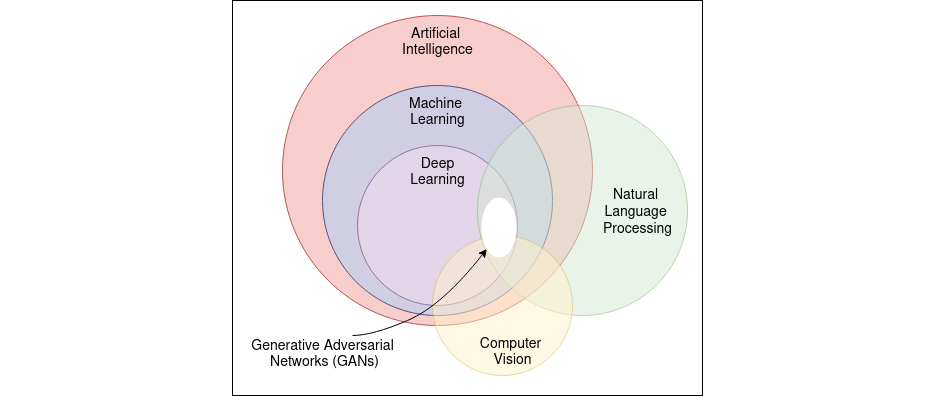
### 什么是对抗学习
定义： 两种模型试图相互削弱并因此相互改进的训练过程称为对抗性学习。

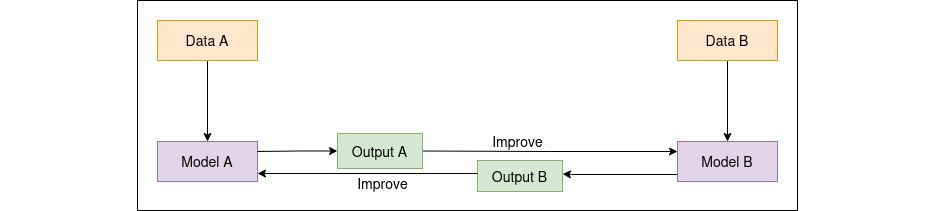

### 生成器网络和鉴别器网络

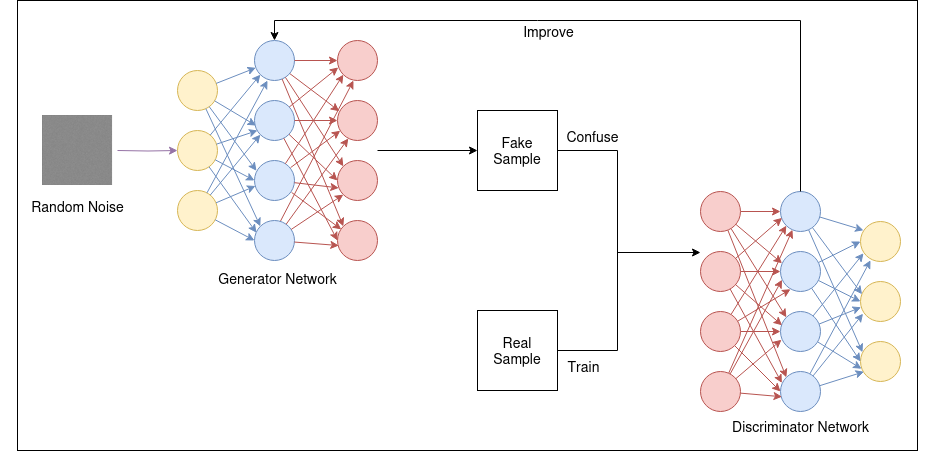

#### 生成器网络

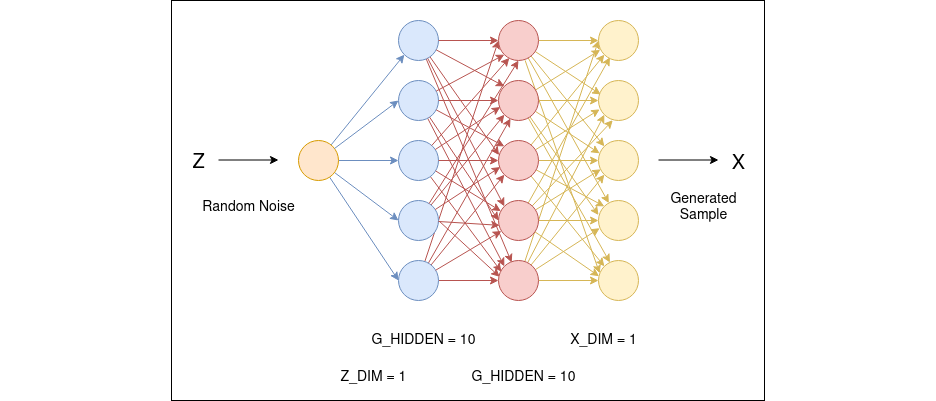

#### 鉴别器网络

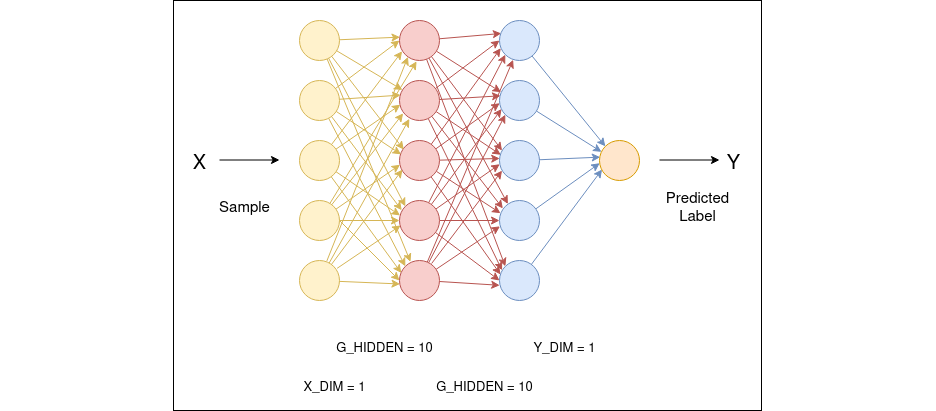

### 激活函数和损失函数

导入numpy和定义模型中需要的几个常量变量

In [1]:
import numpy as np 

Z_DIM = 1
G_HIDDEN = 10
X_DIM = 10
D_HIDDEN = 10
step_size_G = 0.01
step_size_D = 0.01
ITER_NUM = 50000
GRADIENT_CLIP = 0.2
WEIGHT_CLIP = 0.25

定义我们要估计的实正弦样本

In [2]:
def get_samples(random=True):
    if random:
        x0 = np.random.uniform(0, 1)
        freq = np.random.uniform(1.2, 1.5)
        mult = np.random.uniform(0.5, 0.8)
    else:
        x0 = 0
        freq = 0.2
        mult = 1
    signal = [mult * np.sin(x0+freq*i) for i in range(X_DIM)]
    return np.array(signal)

定义激活函数及其导数

In [3]:
def ReLU(x):
    return np.maximum(x, 0.)
def dReLU(x):
    return ReLU(x)
def LeakyReLU(x, k=0.2):
    return np.where(x >= 0, x, x * k)
def dLeakyReLU(x, k=0.2):
    return np.where(x >= 0, 1., k)
def Tanh(x):
    return np.tanh(x)
def dTanh(x):
    return 1. - Tanh(x)**2
def Sigmoid(x):
    return 1. / (1. + np.exp(-x))
def dSigmoid(x):
    return Sigmoid(x) * (1. - Sigmoid(x))

定义一个辅助函数来初始化图层参数

In [4]:
def weight_initializer(in_channels, out_channels):
    scale = np.sqrt(2. / (in_channels + out_channels))
    return np.random.uniform(-scale, scale, (in_channels,
    out_channels))

定义损失函数（正向和后退）

In [5]:
class LossFunc(object):
    def __init__(self):
        self.logit = None
        self.label = None
    def forward(self, logit, label):
        if logit[0, 0] < 1e-7:
            logit[0, 0] = 1e-7
        if 1. - logit[0, 0] < 1e-7:
            logit[0, 0] = 1. - 1e-7
        self.logit = logit
        self.label = label
        return - (label * np.log(logit) + (1-label) * np.log(1- logit))
    def backward(self):
        return (1-self.label) / (1-self.logit) - self.label/self.logit

定义生成器网络的参数

定义正向计算（根据随机噪声生成样本）



x 表示一层的输出值， f 表示激活函数，下标 l 表示该层的索引，隐藏层用ReLU，输出层用Tanh

定义向后计算

1. 计算相对于该层输出的损失到数（例如，相对于 output 或 x2 的导数）
2. 计算相对于参数的损失导数（例如，相对于 w3 或 b3 的导数）
3. 使用导数更新参数
4. 将渐变传递到前一层

In [16]:
class Generator(object):
    def __init__(self):
        self.z = None
        self.w1 = weight_initializer(Z_DIM, G_HIDDEN)
        self.b1 = weight_initializer(1, G_HIDDEN)
        self.x1 = None
        self.w2 = weight_initializer(G_HIDDEN, G_HIDDEN)
        self.b2 = weight_initializer(1, G_HIDDEN)
        self.x2 = None
        self.w3 = weight_initializer(G_HIDDEN, X_DIM)
        self.b3 = weight_initializer(1, X_DIM)
        self.x3 = None
        self.x = None
    
    def forward(self, inputs):
        self.z = inputs.reshape(1, Z_DIM)
        self.x1 = np.matmul(self.z, self.w1) + self.b1
        self.x1 = ReLU(self.x1)
        self.x2 = np.matmul(self.x1, self.w2) + self.b2
        self.x2 = ReLU(self.x2)
        self.x3 = np.matmul(self.x2, self.w3) + self.b3
        self.x = Tanh(self.x3)
        return self.x

    def backward(self, outputs):
        # Derivative with respect to output
        delta = outputs
        delta *= dTanh(self.x)

        # Derivative with respect to w3
        d_w3 = np.matmul(np.transpose(self.x2), delta)
        # Derivative with respect to b3
        d_b3 = delta.copy()

        # Derivative with respect to x2
        delta = np.matmul(delta, np.transpose(self.w3))

        # Update w3
        if (np.linalg.norm(d_w3) > GRADIENT_CLIP):
            d_w3 = GRADIENT_CLIP / np.linalg.norm(d_w3) * d_w3
        self.w3 -= step_size_G * d_w3
        self.w3 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.w3))
        # Update b3
        self.b3 -= step_size_G * d_b3
        self.b3 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.b3))
        delta *= dReLU(self.x2)

        # Derivative with respect to w2
        d_w2 = np.matmul(np.transpose(self.x1), delta)
        # Derivative with respect to b2
        d_b2 = delta.copy()
        # Derivative with respect to x1
        delta = np.matmul(delta, np.transpose(self.w2))
        # Update w2
        if (np.linalg.norm(d_w2) > GRADIENT_CLIP):
            d_w2 = GRADIENT_CLIP / np.linalg.norm(d_w2) * d_w2
        self.w2 -= step_size_G * d_w2
        self.w2 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.w2))
        # Update b2
        self.b2 -= step_size_G * d_b2
        self.b2 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.b2))
        delta *= dReLU(self.x1)

        # Derivative with respect to w1
        d_w1 = np.matmul(np.transpose(self.z), delta)
        # Derivative with respect to b1
        d_b1 = delta.copy()
        # No need to calculate derivative with respect to z
        # Update w1
        if (np.linalg.norm(d_w1) > GRADIENT_CLIP):
            d_w1 = GRADIENT_CLIP / np.linalg.norm(d_w1) * d_w1
        self.w1 -= step_size_G * d_w1
        self.w1 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.w1))
        # Update b1
        self.b1 -= step_size_G * d_b1
        self.b1 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP,self.b1))

定义鉴别器网络

In [13]:
class Discriminator(object):
    def __init__(self):
        self.x = None
        self.w1 = weight_initializer(X_DIM, D_HIDDEN)
        self.b1 = weight_initializer(1, D_HIDDEN)
        self.y1 = None
        self.w2 = weight_initializer(D_HIDDEN, D_HIDDEN)
        self.b2 = weight_initializer(1, D_HIDDEN)
        self.y2 = None
        self.w3 = weight_initializer(D_HIDDEN, 1)
        self.b3 = weight_initializer(1, 1)
        self.y3 = None
        self.y = None
        
    def forward(self, inputs):
        self.x = inputs.reshape(1, X_DIM)
        self.y1 = np.matmul(self.x, self.w1) + self.b1
        self.y1 = LeakyReLU(self.y1)
        self.y2 = np.matmul(self.y1, self.w2) + self.b2
        self.y2 = LeakyReLU(self.y2)
        self.y3 = np.matmul(self.y2, self.w3) + self.b3
        self.y = Sigmoid(self.y3)
        return self.y

    def backward(self, outputs, apply_grads=True):
        # Derivative with respect to output
        delta = outputs
        delta *= dSigmoid(self.y)
        # Derivative with respect to w3
        d_w3 = np.matmul(np.transpose(self.y2), delta)
        # Derivative with respect to b3
        d_b3 = delta.copy()
        # Derivative with respect to y2
        delta = np.matmul(delta, np.transpose(self.w3))
        if apply_grads:
            # Update w3
            if np.linalg.norm(d_w3) > GRADIENT_CLIP:
                d_w3 = GRADIENT_CLIP / np.linalg.norm(d_w3) * d_w3
            self.w3 += step_size_D * d_w3
            self.w3 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.w3))
            # Update b3
            self.b3 += step_size_D * d_b3
            self.b3 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.b3))
        delta *= dLeakyReLU(self.y2)
        # Derivative with respect to w2
        d_w2 = np.matmul(np.transpose(self.y1), delta)
        # Derivative with respect to b2
        d_b2 = delta.copy()
        # Derivative with respect to y1
        delta = np.matmul(delta, np.transpose(self.w2))
        if apply_grads:
            # Update w2
            if np.linalg.norm(d_w2) > GRADIENT_CLIP:
                d_w2 = GRADIENT_CLIP / np.linalg.norm(d_w2) * d_w2
            self.w2 += step_size_D * d_w2
            self.w2 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.w2))
            # Update b2
            self.b2 += step_size_D * d_b2
            self.b2 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.b2))
        delta *= dLeakyReLU(self.y1)
        # Derivative with respect to w1
        d_w1 = np.matmul(np.transpose(self.x), delta)
        # Derivative with respect to b1
        d_b1 = delta.copy()
        # Derivative with respect to x
        delta = np.matmul(delta, np.transpose(self.w1))
        # Update w1
        if apply_grads:
            if np.linalg.norm(d_w1) > GRADIENT_CLIP:
                d_w1 = GRADIENT_CLIP / np.linalg.norm(d_w1) * d_w1
            self.w1 += step_size_D * d_w1
            self.w1 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.w1))
            # Update b1
            self.b1 += step_size_D * d_b1
            self.b1 = np.maximum(-WEIGHT_CLIP, np.minimum(WEIGHT_CLIP, self.b1))
        return delta

训练GAN网络
1. 使用真实数据训练鉴别器（并将其识别为真实数据
2. 使用虚假数据训练鉴别器（并将其识别为虚假
3. 使用虚假数据训练生成器（并将其识别为真实数据）

In [17]:
G = Generator()
D = Discriminator()
criterion = LossFunc()
real_label = 1
fake_label = 0
for itr in range(ITER_NUM):
    # Update D with real data
    x_real = get_samples(True)
    y_real = D.forward(x_real)
    loss_D_r = criterion.forward(y_real, real_label)
    d_loss_D = criterion.backward()
    D.backward(d_loss_D)
    # Update D with fake data
    z_noise = np.random.randn(Z_DIM)
    x_fake = G.forward(z_noise)
    y_fake = D.forward(x_fake)
    loss_D_f = criterion.forward(y_fake, fake_label)
    d_loss_D = criterion.backward()
    D.backward(d_loss_D)
    # Update G with fake data
    y_fake_r = D.forward(x_fake)
    loss_G = criterion.forward(y_fake_r, real_label)
    d_loss_G = D.backward(loss_G, apply_grads=False)
    G.backward(d_loss_G)
    loss_D = loss_D_r + loss_D_f
    if itr % 100 == 0:
        print('{} {} {}'.format(loss_D_r.item((0, 0)), loss_D_f.item((0,0)), loss_G.item((0, 0))))

0.9407148465156681 0.5701714338227638 0.19799750312332373
0.8388992193135967 0.5694820131869007 0.19827844142227874
0.8560799270589634 0.5656127535471908 0.19957860713707481
0.8791241043563095 0.560942608801774 0.20109697199846457
0.9406925554161358 0.5562794037611172 0.20268394806499598
1.0376632197649516 0.54937705288638 0.20506095306381222
1.1320310641788058 0.5359396171828855 0.2097727356465678
1.1835193367266554 0.5203864576167051 0.2154840874088038
1.2564235622863007 0.5018706765285394 0.2225870659551708
1.2310004045121894 0.49162824088602164 0.2266331315285981
1.1735287570440947 0.4785808555648955 0.23198500567480934
1.1867795583239145 0.4646701118379625 0.23784754735426433
1.1680836007498385 0.45109920339052106 0.2438115499185158
1.1836178744844945 0.4359707283167654 0.2507251788189025
1.1660731669695397 0.4162369524517607 0.2602112568541911
1.1909888680385847 0.4077996329864559 0.26441499962796744
1.1666502756568815 0.399965198696404 0.26847516090235385
1.2567268679021897 0.39

可视化生成样本呢

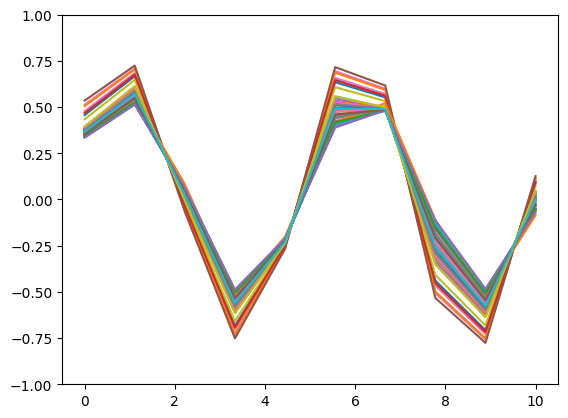

In [18]:
import matplotlib.pyplot as plt
x_axis = np.linspace(0, 10, 10)
for i in range(50):
    z_noise = np.random.randn(Z_DIM)
    x_fake = G.forward(z_noise)
    plt.plot(x_axis, x_fake.reshape(X_DIM))
plt.ylim((-1, 1))
plt.show()

## 模型设计和训练的最佳实践

### Vanilla convolution

核心思想： 这是最基础的卷积操作。它使用一个完整的过滤器（或核）来滑动并扫描整个输入特征图的每个通道，以生成单个输出特征图。

    计算过程： 假设输入有 Cin​ 个通道，你使用 Cout​ 个过滤器。每个过滤器的大小为 Hk​×Wk​×Cin​。每个过滤器都会对输入的所有通道进行卷积，然后将结果相加，得到输出特征图的一个通道。这个过程重复 Cout​ 次。

    参数数量： Hk​×Wk​×Cin​×Cout​

    优点： 简单直接，是大多数 CNN 的基础。

    缺点： 参数量和计算量大，尤其是在输入和输出通道数很多时。

In [ ]:
class ReLUConvBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super(ReLUConvBN, self).__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_out, kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(C_out, affine=affine)
        )

    def forward(self, x):
        return self.op(x)

### Grouped convolution

核心思想： 将输入特征图的通道和卷积核分成多个组，然后在每个组内独立进行卷积。

    计算过程： 假设输入有 Cin​ 个通道，输出有 Cout​ 个通道，并且你将它们分成 G 个组。每个组的输入通道数为 Cin​/G，输出通道数为 Cout​/G。每个组内的卷积操作独立进行，最后将所有组的输出拼接起来。

    参数数量： (Hk​×Wk​×Cin​/G)×(Cout​/G)×G=Hk​×Wk​×Cin​×Cout​/G

    优点： 大大减少了参数量和计算量，是香草卷积的 1/G 倍。这使得模型更轻量，训练更快。

    应用： 最早由 AlexNet 提出，现在是许多轻量级网络（如 MobileNetV1/V2）和大型网络（如 ResNeXt）的基础。

### Depthwise separable convolution

核心思想： 将香草卷积分解为两个更简单的步骤：深度卷积和逐点卷积。

    深度卷积 (Depthwise Convolution)：

        使用与输入通道数相同的过滤器数量。

        每个过滤器只负责一个通道，不跨通道。

        参数数量：Hk​×Wk​×Cin​

    逐点卷积 (Pointwise Convolution)：

        使用 1×1 的卷积核。

        这个卷积核负责将深度卷积的输出进行线性组合，生成最终的输出通道。

        参数数量：1×1×Cin​×Cout​

    总参数数量： (Hk​×Wk​×Cin​)+(1×1×Cin​×Cout​)

    优点： 相较于香草卷积，参数量和计算量显著减少。它是移动设备上轻量级模型（如 MobileNetV1）的核心。

    缺点： 可能会在一定程度上牺牲模型的表达能力。

In [ ]:
class SepConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super(SepConv, self).__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size=kernel_size, stride=stride, 
                      padding=padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size=kernel_size, stride=1, 
                      padding=padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine)
        )

    def forward(self, x):
        return self.op(x)

### Dilation convolution

核心思想： 在卷积核的元素之间插入空洞（zeros），从而在不增加参数和计算量的情况下，扩大感受野（Receptive Field）。

    计算过程： 一个 3×3 的空洞卷积，空洞率为 1（Dilation Rate=1）时，等同于标准的 3×3 卷积。但当空洞率为 2 时，卷积核会跳过中间的像素点，实现 5×5 的感受野，但实际计算量和参数量仍是 3×3。

    参数数量： 保持不变，与香草卷积相同 (Hk​×Wk​×Cin​×Cout​)。

    优点： 在保持计算效率的同时，能够捕捉更广阔的上下文信息，这对于语义分割、目标检测等任务至关重要。

    缺点： 空洞率的选择不当可能导致“网格效应”（Gridding Effect），即部分像素信息被跳过，无法被有效利用。

In [ ]:
class DilConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation, affine=True):
        super(DilConv, self).__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size=kernel_size, stride=stride, padding=padding, 
            dilation=dilation, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine)
        )
    def forward(self, x):
        return self.op(x)

### 上采样和下采样

**增加张量大小的过程称为上采样**

**减少张量大小的过程称为下采样**

下采样通常比上采样更棘手，因为我们不想在较小的张量中丢失太多有用的信息。

下采样的方法

- Max-pooling

    eg：nn.MaxPool2d

- Average-pooling

    eg: nn.AvgPool2d | nn.AdaptiveAvgPool2d

- Strided convolution

    eg: 小批量张量 [32,8,256,256]通常会被下采样 [32,16,128,128]以便输出张量包含与输入张量相似的信息量。
    
- Factorized reduction

In [ ]:
class FactorizedReduce(nn.Module):
    def __init__(self, C_in, C_out, affine=True):
        super(FactorizedReduce, self).__init__()
        assert C_out % 2 == 0
        self.relu = nn.ReLU(inplace=False)
        self.conv_1 = nn.Conv2d(C_in, C_out // 2, 1, stride=2, padding=0, bias=False)
        self.conv_2 = nn.Conv2d(C_in, C_out // 2, 1, stride=2, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(C_out, affine=affine)
    def forward(self, x):
        x = self.relu(x)
        out = torch.cat([self.conv_1(x), self.conv_2(x[:,:,1:,1:])], dim=1)
        out = self.bn(out)
        return out

### 参数和损失函数

这些术语都与深度学习中**初始化神经网络权重**的方法有关，特别是针对不同的激活函数。它们的目的是为了解决训练初期梯度消失或梯度爆炸的问题，确保模型能够稳定地开始学习。

以下是它们的区别：

### 1. 均匀分布（Uniform）和正态分布（Normal）

这是两种基本的随机分布，是其他初始化方法的基础。

* **Uniform（均匀分布）**：从一个指定的区间 $[a, b]$ 中随机抽取数值，区间内的每个数值被抽取的概率相等。
* **Normal（正态分布）**：也称高斯分布。从一个指定的均值 $\mu$ 和标准差 $\sigma$ 中抽取数值，呈钟形曲线分布，中间的数值被抽取的概率最高。

### 2. Xavier 初始化

**核心思想**：为了让网络中每一层的激活值方差保持一致，防止在深度网络中信号的方差过大或过小，从而抑制梯度消失或爆炸。它假设激活函数是线性的（如 sigmoid 或 tanh）。

* **Xavier-uniform（也称 Glorot-uniform）**：从一个均匀分布中随机抽取权重。其范围由**输入神经元数**和**输出神经元数**决定。
    $W \sim U(-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}})$
* **Xavier-normal（也称 Glorot-normal）**：从一个正态分布中随机抽取权重。其标准差由**输入神经元数**和**输出神经元数**决定。
    $W \sim N(0, \sqrt{\frac{2}{n_{in} + n_{out}}})$

### 3. He 初始化

**核心思想**：是 Xavier 初始化的改进版，专门为 **ReLU 及其变种**（如 Leaky ReLU）设计。由于 ReLU 会让一半的神经元输出为零，He 初始化只考虑**输入神经元数**，来补偿这种信息损失，确保方差在正向和反向传播中保持稳定。

* **He-uniform**：从一个均匀分布中随机抽取权重。其范围只由**输入神经元数**决定。
    $W \sim U(-\sqrt{\frac{6}{n_{in}}}, \sqrt{\frac{6}{n_{in}}})$
* **He-normal**：从一个正态分布中随机抽取权重。其标准差只由**输入神经元数**决定。
    $W \sim N(0, \sqrt{\frac{2}{n_{in}}})$

### 4. 截断正态分布（Truncated Normal）

**核心思想**：是对标准正态分布的一种改进，通常与 He 和 Xavier 初始化结合使用。

* **Truncated Normal**：从一个正态分布中抽取数值，但**会丢弃**超出指定范围（例如均值正负两个标准差）的数值，然后重新抽取，直到所有数值都在指定范围内。
* **优点**：它确保了所有初始权重都在一个合理的范围内，避免了极大的初始值导致梯度爆炸的风险，使训练更加稳定。许多现代框架（如 TensorFlow）的默认初始化器会使用这种方式。

### 总结对比
| 初始化方法 | 基础分布 | 适用激活函数 | 关键参数 | 优点 |
| :--- | :--- | :--- | :--- | :--- |
| **Xavier-uniform** | 均匀 | Sigmoid, tanh | $n_{in}, n_{out}$ | 保持方差稳定 |
| **Xavier-normal** | 正态 | Sigmoid, tanh | $n_{in}, n_{out}$ | 保持方差稳定 |
| **He-uniform** | 均匀 | **ReLU 及其变种** | $n_{in}$ | 解决了 ReLU 的零激活问题 |
| **He-normal** | 正态 | **ReLU 及其变种** | $n_{in}$ | 解决了 ReLU 的零激活问题 |
| **Truncated Normal** | 正态 | 通用 | 均值，标准差，截断范围 | 避免极端值，增强训练稳定性 |

In [ ]:
import numpy as np
from scipy import stats
import torch
import torch.nn as nn
import math

def initializer_conv(shape, init='he', dist='truncnorm', dist_scale=1.0):
    w_width = shape[3]
    w_height = shape[2]
    size_in = shape[1]
    size_out = shape[0]
    limit = 0.

    if init == 'xavier':
        limit = math.sqrt(2. / (w_width * w_height * (size_in + size_out))) * dist_scale
    elif init == 'he':
        limit = math.sqrt(2. / (w_width * w_height * size_in)) * dist_scale
    else:
        raise Exception('Arg `init` not recognized.')

    if dist == 'norm':
        var = np.array(stats.norm(loc=0, scale=limit).rvs(shape)).astype(np.float32)
    elif dist == 'truncnorm':
        var = np.array(stats.truncnorm(a=-2, b=2, scale=limit).rvs(shape)).astype(np.float32)
    elif dist == 'uniform':
        var = np.array(stats.uniform(loc=-limit, scale=2*limit).rvs(shape)).astype(np.float32)
    else:
        raise Exception('Arg `dist` not recognized.')

    return var

class Conv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, dilation=1, groups=1, bias=True,
                 init='he', dist='truncnorm', dist_scale=1.0):
        super(Conv2d, self).__init__(
            in_channels, out_channels, kernel_size, stride,
            padding, dilation, groups, bias)
        self.weight = nn.Parameter(torch.Tensor(
            initializer_conv([out_channels, in_channels // groups, kernel_size, kernel_size],
                             init=init, dist=dist, dist_scale=dist_scale))
        )

### 优化和学习率

这些术语都指的是深度学习中的**优化器（Optimizer）**，它们是用来更新模型参数（如权重和偏置）以最小化损失函数的算法。

可以把损失函数想象成一个山谷，我们的目标是找到它的最低点。优化器就是我们下山的方法。

---

### 1. SGD (Stochastic Gradient Descent)

**核心思想**：最简单、最基础的下山方法。每走一步，都只根据**当前脚下**的坡度（梯度）方向来决定下一步怎么走。

* **工作原理**：每次只使用一小批数据（mini-batch）来计算梯度，并沿着梯度的反方向更新参数。
* **缺点**：
    * **震荡**：如果山谷很陡峭，SGD 可能会在山谷两侧反复震荡，前进缓慢。
    * **陷入局部最优**：可能在到达最低点之前，就停在了一个小坑里（局部最小值）。
* **比喻**：一个喝醉酒的人，每走一步都只看脚下，摇摇晃晃地下山。

---

### 2. Momentum (动量)

**核心思想**：在 SGD 的基础上加入了“惯性”。它不仅考虑当前方向，还考虑之前的移动方向。

* **工作原理**：引入一个动量项。每次更新时，参数的移动方向是**当前梯度**和**上一次更新方向**的加权和。这让模型在同一方向上持续前进，减少震荡。
* **优点**：
    * **加速收敛**：能更快地穿越平坦区域。
    * **减少震荡**：有效地抑制了 SGD 在陡峭山谷中的来回震荡。
* **比喻**：一个滑雪者，利用下坡的惯性，能快速滑过平地，减少摇摆。

---

### 3. Nesterov (Nesterov Accelerated Gradient, NAG)

**核心思想**：对 Momentum 的改进，更加“聪明”。它在更新前会先“向前看一步”。

* **工作原理**：Nesterov 不会直接使用当前位置的梯度，而是先沿着 Momentum 的方向“向前走一小步”，然后在这个**预测位置**上计算梯度，并用这个梯度来更新参数。
* **优点**：比 Momentum 收敛更快，因为它能更早地“预见”到山谷的坡度变化，避免冲过最低点。
* **比喻**：一个聪明的滑雪者，会提前预判前方坡度，调整姿态，更精确地滑向终点。

---

### 4. AdaGrad (Adaptive Gradient)

**核心思想**：引入**自适应学习率**，让每个参数都有自己的学习率。

* **工作原理**：它会记录每个参数过去梯度的平方和。对于那些更新频繁的参数（梯度大），学习率会逐渐**减小**；对于那些更新较少的参数（梯度小），学习率会保持或**增大**。
* **优点**：
    * 能自动调整学习率，无需手动调整。
    * 对于稀疏数据（如文本数据），效果很好。
* **缺点**：学习率会单调持续减小，最终变得极小，导致模型无法继续学习。
* **比喻**：一个下山的人，走在平地上时步子大，但遇到陡峭、难走的路时，步子会越来越小，甚至停下。

---

### 5. RMSprop (Root Mean Square Propagation)

**核心思想**：为了解决 AdaGrad 学习率单调递减的问题。

* **工作原理**：它不再累积所有梯度的平方和，而是只计算**最近一段时间内**梯度平方的指数加权平均。这使得它能够适应非平稳的目标，防止学习率变得过小。
* **优点**：解决了 AdaGrad 学习率下降过快的问题，通常比 AdaGrad 表现更好。
* **比喻**：一个下山的人，他会忘记很久以前走过的路，只记住最近的路况，从而能根据当前的坡度灵活调整步子。

---

### 6. Adam (Adaptive Moment Estimation)

**核心思想**：**结合了 Momentum 和 RMSprop 的优点**，是目前最常用、效果最好的优化器之一。

* **工作原理**：
    * 它像 **Momentum** 一样，追踪梯度的**一阶矩**（即梯度的指数加权平均，相当于动量）。
    * 它像 **RMSprop** 一样，追踪梯度的**二阶矩**（即梯度平方的指数加权平均，相当于自适应学习率）。
    * 它用一阶矩和二阶矩来计算更新步长。
* **优点**：
    * **自适应学习率**：每个参数都有自己的学习率。
    * **动量加速**：像动量一样能够加速收敛。
    * **对超参数不敏感**：在大多数情况下表现良好，无需太多手动调整。
* **比喻**：一个经验丰富的登山者，他既能利用惯性加速前进，又能根据不同地形调整步子，非常高效。

---

### 总结对比

| 优化器 | 核心思想 | 关键机制 | 优点 | 缺点/适用性 |
| :--- | :--- | :--- | :--- | :--- |
| **SGD** | 梯度下降 | 基于 mini-batch 的梯度 | 简单，基础 | 震荡，收敛慢 |
| **Momentum**| 惯性 | 动量项 | 减少震荡，加速收敛 | 仍需要手动调整学习率 |
| **Nesterov**| 预判惯性 | 预测位置的梯度 | 比 Momentum 收敛更快更准 | 仍需要手动调整学习率 |
| **AdaGrad**| 自适应学习率 | 累积梯度平方 | 自动调整，适合稀疏数据 | 学习率单调递减，过早停止训练 |
| **RMSprop**| 解决 AdaGrad 问题 | 梯度的指数加权平均 | 解决了学习率过快下降的问题 | 仍需要手动调整学习率 |
| **Adam** | 动量 + 自适应学习率 | 梯度的1阶和2阶矩 | 性能全面，普遍适用，调参少 | 有时会收敛到次优解 |

### 调整学习率

In [ ]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)
for epoch in range(epochs):
    ...
    scheduler.step()

In [ ]:
class LRScheduleCosine(object):
    def __init__(self, optimizer, epoch=0, epoch_start=0, lr_max=0.05,lr_min=0.001, t_mul=10):
        self.optimizer = optimizer
        self.epoch = epoch
        self.lr_min = lr_min
        self.lr_max = lr_max
        self.t_start = epoch_start
        self.t_mul = t_mul
        self.lr = lr_max
    def step(self):
        self.epoch += 1
        self.lr = self.lr_min + 0.5*(self.lr_max- self.lr_min)*(1.+math.cos
        (math.pi*(self.epoch-self.t_start)/self.t_mul))
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = self.lr
        if self.epoch == self.t_start + self.t_mul:
            self.t_start += self.t_mul
            self.t_mul *= 2
        return self.lr

In [ ]:
scheduler = LRScheduleCosine(optimizer, lr_max=0.025,lr_min=0.001,t_mul=10)
for epoch in range(epochs):
    lr = scheduler.step()
    ...

## 深度卷积对抗生成网络（DCGAN）

生成器

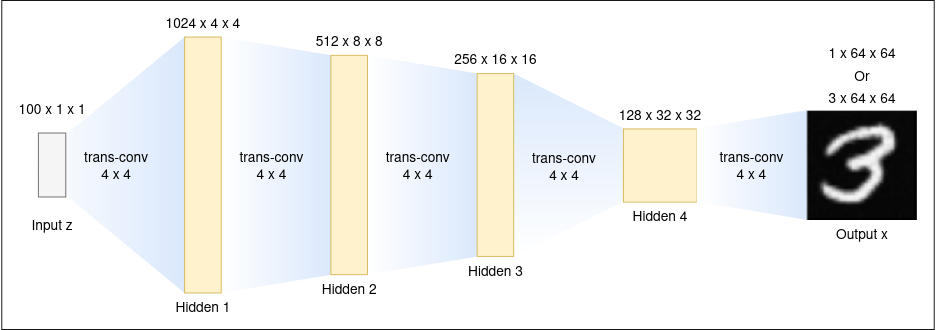

鉴别器

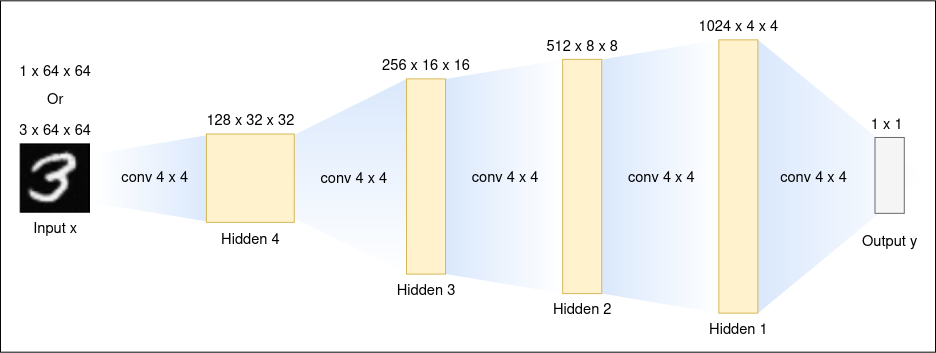

In [14]:
import errno
import os
import shutil
import sys


def to_np(var):
    """Exports torch.Tensor to Numpy array.
    """
    return var.detach().cpu().numpy()


def create_folder(folder_path):
    """Create a folder if it does not exist.
    """
    try:
        os.makedirs(folder_path)
    except OSError as _e:
        if _e.errno != errno.EEXIST:
            raise


def clear_folder(folder_path):
    """Clear all contents recursively if the folder exists.
    Create the folder if it has been accidently deleted.
    """
    create_folder(folder_path)
    for the_file in os.listdir(folder_path):
        _file_path = os.path.join(folder_path, the_file)
        try:
            if os.path.isfile(_file_path):
                os.unlink(_file_path)
            elif os.path.isdir(_file_path):
                shutil.rmtree(_file_path)
        except OSError as _e:
            print(_e)


class StdOut(object):
    """Redirect stdout to file, and print to console as well.
    """
    def __init__(self, output_file):
        self.terminal = sys.stdout
        self.log = open(output_file, "a")

    def write(self, message):
        self.terminal.write(message)
        self.terminal.flush()
        self.log.write(message)
        self.log.flush()

    def flush(self):
        self.terminal.flush()
        self.log.flush()

In [16]:
import os
import sys

import numpy as np
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils


CUDA = True     # Change to False for CPU training
DATA_PATH = '~/Data/mnist'   # -> '/media/john/FastData/CelebA' or '/media/john/FastData/lsun' 
OUT_PATH = 'output'
LOG_FILE = os.path.join(OUT_PATH, 'log.txt')
BATCH_SIZE = 128        # Adjust this value according to your GPU memory
IMAGE_CHANNEL = 1  # -> 3


# 2. Define key variables required to generate images
Z_DIM = 100
G_HIDDEN = 64
X_DIM = 64
D_HIDDEN = 64
EPOCH_NUM = 25
REAL_LABEL = 1
FAKE_LABEL = 0
lr = 2e-4
seed = 1   # Change to None to get different results at each run

clear_folder(OUT_PATH)
print("Logging to {}\n".format(LOG_FILE))
sys.stdout = StdOut(LOG_FILE)
CUDA = CUDA and torch.cuda.is_available()
print("PyTorch version: {}".format(torch.__version__))
if CUDA:
    print("CUDA version: {}\n".format(torch.version.cuda))

if seed is None:
    seed = np.random.randint(1, 10000)
print("Random Seed: ", seed)
np.random.seed(seed)
torch.manual_seed(seed)
if CUDA:
    torch.cuda.manual_seed(seed)
cudnn.benchmark = True      # May train faster but cost more memory

# load data 
# for CelebA
# dataset = dset.ImageFolder(root=DATA_PATH,
#                             transform=transforms.Compose([
#                             transforms.Resize(X_DIM),
#                             transforms.CenterCrop(X_DIM),
#                             transforms.ToTensor(),
#                             transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
#                             ]))
#
# for lsun
# dataset = dset.LSUN(root=DATA_PATH, classes=['bedroom_train'],
#                     transform=transforms.Compose([
#                     transforms.Resize(X_DIM),
#                     transforms.CenterCrop(X_DIM),
#                     transforms.ToTensor(),
#                     transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
#                     ]))
dataset = dset.MNIST(root=DATA_PATH, download=True,
                     transform=transforms.Compose([
                     transforms.Resize(X_DIM),
                     transforms.ToTensor(),
                     transforms.Normalize((0.5,), (0.5,))
                     ]))
assert dataset
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE,
                                         shuffle=True, num_workers=4)

device = torch.device("cuda:0" if CUDA else "cpu")


def weights_init(m):
    """
    custom weights initialization
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

# 3. Define generator network
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # 1st layer
            nn.ConvTranspose2d(Z_DIM, G_HIDDEN * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 8),
            nn.ReLU(True),
            # 2nd layer
            nn.ConvTranspose2d(G_HIDDEN * 8, G_HIDDEN * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 4),
            nn.ReLU(True),
            # 3rd layer
            nn.ConvTranspose2d(G_HIDDEN * 4, G_HIDDEN * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 2),
            nn.ReLU(True),
            # 4th layer
            nn.ConvTranspose2d(G_HIDDEN * 2, G_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN),
            nn.ReLU(True),
            # output layer
            nn.ConvTranspose2d(G_HIDDEN, IMAGE_CHANNEL, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# 4. Define discriminator network
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # 1st layer
            nn.Conv2d(IMAGE_CHANNEL, D_HIDDEN, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 2nd layer
            nn.Conv2d(D_HIDDEN, D_HIDDEN * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 3rd layer
            nn.Conv2d(D_HIDDEN * 2, D_HIDDEN * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # 4th layer
            nn.Conv2d(D_HIDDEN * 4, D_HIDDEN * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # output layer
            nn.Conv2d(D_HIDDEN * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)


netG = Generator().to(device)
netG.apply(weights_init)
print(netG)

netD = Discriminator().to(device)
netD.apply(weights_init)
print(netD)

criterion = nn.BCELoss()

viz_noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1, device=device)

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))

# 5. Train model
for epoch in range(EPOCH_NUM):
    for i, data in enumerate(dataloader):
        x_real = data[0].to(device)
        real_label = torch.full((x_real.size(0),), REAL_LABEL, device=device, dtype=torch.float)
        fake_label = torch.full((x_real.size(0),), FAKE_LABEL, device=device, dtype=torch.float)

        # Update D with real data
        netD.zero_grad()
        y_real = netD(x_real)
        loss_D_real = criterion(y_real, real_label)
        loss_D_real.backward()

        # Update D with fake data
        z_noise = torch.randn(x_real.size(0), Z_DIM, 1, 1, device=device)
        x_fake = netG(z_noise)
        y_fake = netD(x_fake.detach())
        loss_D_fake = criterion(y_fake, fake_label)
        loss_D_fake.backward()
        optimizerD.step()

        # Update G with fake data
        netG.zero_grad()
        y_fake_r = netD(x_fake)
        loss_G = criterion(y_fake_r, real_label)
        loss_G.backward()
        optimizerG.step()

        if i % 100 == 0:
            print('Epoch {} [{}/{}] loss_D_real: {:.4f} loss_D_fake: {:.4f} loss_G: {:.4f}'.format(
                epoch, i, len(dataloader),
                loss_D_real.mean().item(),
                loss_D_fake.mean().item(),
                loss_G.mean().item()
            ))
            vutils.save_image(x_real, os.path.join(OUT_PATH, 'real_samples.png'), normalize=True)
            with torch.no_grad():
                viz_sample = netG(viz_noise)
                vutils.save_image(viz_sample, os.path.join(OUT_PATH, 'fake_samples_{}.png'.format(epoch)), normalize=True)
    torch.save(netG.state_dict(), os.path.join(OUT_PATH, 'netG_{}.pth'.format(epoch)))
    torch.save(netD.state_dict(), os.path.join(OUT_PATH, 'netD_{}.pth'.format(epoch)))

### 模型使用

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.parallel
from torchvision.utils import save_image
from PIL import Image
from IPython.display import Image as IPImage, display

In [ ]:
Z_DIM = 100
IMAGE_CHANNEL=1
G_HIDDEN = 64
X_DIM = 64
D_HIDDEN = 64
lr = 2e-4
seed = 1
num_images = 64 
device = torch.device('cpu') 

In [ ]:
class Generator(nn.Module):
       def __init__(self):
           super(Generator, self).__init__()
           self.main = nn.Sequential(
               # 1st layer
               nn.ConvTranspose2d(Z_DIM, G_HIDDEN * 8, 4, 1, 0, bias=False),
               nn.BatchNorm2d(G_HIDDEN * 8),
               nn.ReLU(True),
               # 2nd layer
               nn.ConvTranspose2d(G_HIDDEN * 8, G_HIDDEN * 4, 4, 2, 1,
   bias=False),
               nn.BatchNorm2d(G_HIDDEN * 4),
               nn.ReLU(True),
               # 3rd layer
               nn.ConvTranspose2d(G_HIDDEN * 4, G_HIDDEN * 2, 4, 2, 1,
   bias=False),
               nn.BatchNorm2d(G_HIDDEN * 2),
               nn.ReLU(True),
               # 4th layer
               nn.ConvTranspose2d(G_HIDDEN * 2, G_HIDDEN, 4, 2, 1,
   bias=False),
               nn.BatchNorm2d(G_HIDDEN),
               nn.ReLU(True),
               # output layer
               nn.ConvTranspose2d(G_HIDDEN, IMAGE_CHANNEL, 4, 2, 1,
               bias=False),
               nn.Tanh()
)
       def forward(self, input):
           return self.main(input)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

In [ ]:
def load_generator(model_path):
    generator = Generator()
    generator.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    generator.eval()
    return generator

In [ ]:
model_1_path = 'Models/DCGAN_MNIST/netG_1.pth'
model_25_path = 'Models/DCGAN_MNIST/netG_25.pth'

In [ ]:
generator_1 = load_generator(model_1_path)
generator_25 = load_generator(model_25_path)

In [ ]:
def generate_images(generator, num_images, Z_DIM, device):
    images = []
    for _ in range(num_images):
        noise = torch.randn(1, Z_DIM, 1, 1, device=device)
        generated_image = generator(noise)
        images.append(generated_image)
    return images

In [ ]:
images_epoch_1 = generate_images(generator_1, num_images, Z_DIM, device)
images_epoch_25 = generate_images(generator_25, num_images, Z_DIM, device)

In [ ]:
def combine_images(image_list):
    combined = torch.cat(image_list, dim=0)
    return combined

In [ ]:
combined_image_epoch_1 = combine_images(images_epoch_1)
combined_image_epoch_25 = combine_images(images_epoch_25)

In [ ]:
output_dir = 'output'  
os.makedirs(output_dir, exist_ok=True)

In [ ]:
save_image(combined_image_epoch_1, os.path.join(output_dir, 'combined_image_epoch_1.png'), nrow=8)
save_image(combined_image_epoch_25, os.path.join(output_dir, 'combined_image_epoch_25.png'), nrow=8)

In [ ]:
def display_combined_images(image_paths, title):
    image1 = Image.open(image_paths[0])
    image2 = Image.open(image_paths[1])

    # Make sure both images have the same dimensions
    if image1.size != image2.size:
        print("Image dimensions do not match. Resizing images...")
        image1 = image1.resize(image2.size)

    # Create a new image to combine them
    combined_image = Image.new("RGB", (image1.width + image2.width, image1.height))

    # Paste the first image on the left side
    combined_image.paste(image1, (0, 0))

    # Paste the second image on the right side
    combined_image.paste(image2, (image1.width, 0))

    combined_image_path = os.path.join(output_dir, 'combined_image.png')
    combined_image.save(combined_image_path)
    display(IPImage(combined_image_path))

In [ ]:
image_paths = [os.path.join(output_dir, 'combined_image_epoch_1.png'), os.path.join(output_dir, 'combined_image_epoch_25.png')]
display_combined_images(image_paths, "Combined Images (Epoch 1 and Epoch 25)")

#### Test

In [18]:
import os
import sys

from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torchvision.utils as vutils

from scipy.interpolate import interp1d


CUDA = False     # Change to False for CPU training
VIZ_MODE = 0    # 0: random; 1: interpolation; 2: semantic calculation
OUT_PATH = 'output'
LOG_FILE = os.path.join(OUT_PATH, 'log.txt')
BATCH_SIZE = 10        # Adjust this value according to your GPU memory
IMAGE_CHANNEL = 1
# IMAGE_CHANNEL = 3
Z_DIM = 100
G_HIDDEN = 64
X_DIM = 64
D_HIDDEN = 64
seed = None            # Change to None to get different results at each run

print("Logging to {}\n".format(LOG_FILE))
sys.stdout = StdOut(LOG_FILE)
CUDA = CUDA and torch.cuda.is_available()
print("PyTorch version: {}".format(torch.__version__))
if CUDA:
    print("CUDA version: {}\n".format(torch.version.cuda))

if seed is None:
    seed = np.random.randint(1, 10000)
print("Random Seed: ", seed)
np.random.seed(seed)
torch.manual_seed(seed)
if CUDA:
    torch.cuda.manual_seed(seed)
cudnn.benchmark = True      # May train faster but cost more memory

device = torch.device("cuda:0" if CUDA else "cpu")


class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # 1st layer
            nn.ConvTranspose2d(Z_DIM, G_HIDDEN * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 8),
            nn.ReLU(True),
            # 2nd layer
            nn.ConvTranspose2d(G_HIDDEN * 8, G_HIDDEN * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 4),
            nn.ReLU(True),
            # 3rd layer
            nn.ConvTranspose2d(G_HIDDEN * 4, G_HIDDEN * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 2),
            nn.ReLU(True),
            # 4th layer
            nn.ConvTranspose2d(G_HIDDEN * 2, G_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN),
            nn.ReLU(True),
            # output layer
            nn.ConvTranspose2d(G_HIDDEN, IMAGE_CHANNEL, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)


netG = Generator()
netG.load_state_dict(torch.load(os.path.join(OUT_PATH, 'netG_24.pth')))
netG.to(device)

if VIZ_MODE == 0:
    viz_tensor = torch.randn(BATCH_SIZE, Z_DIM, 1, 1, device=device)
elif VIZ_MODE == 1:
    load_vector = np.loadtxt('vec_20190317-223131.txt')
    xp = [0, 1]
    yp = np.vstack([load_vector[2], load_vector[9]])   # choose two exemplar vectors
    xvals = np.linspace(0, 1, num=BATCH_SIZE)
    sample = interp1d(xp, yp, axis=0)
    viz_tensor = torch.tensor(sample(xvals).reshape(BATCH_SIZE, Z_DIM, 1, 1), dtype=torch.float32, device=device)
elif VIZ_MODE == 2:
    load_vector = np.loadtxt('vec_20190317-223131.txt')
    z1 = (load_vector[0] + load_vector[6] + load_vector[8]) / 3.
    z2 = (load_vector[1] + load_vector[2] + load_vector[4]) / 3.
    z3 = (load_vector[3] + load_vector[4] + load_vector[6]) / 3.
    z_new = z1 - z2 + z3
    sample = np.zeros(shape=(BATCH_SIZE, Z_DIM))
    for i in range(BATCH_SIZE):
        sample[i] = z_new + 0.1 * np.random.normal(-1.0, 1.0, 100)
    viz_tensor = torch.tensor(sample.reshape(BATCH_SIZE, Z_DIM, 1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    viz_sample = netG(viz_tensor)
    viz_vector = to_np(viz_tensor).reshape(BATCH_SIZE, Z_DIM)
    cur_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    np.savetxt('vec_{}.txt'.format(cur_time), viz_vector)
    vutils.save_image(viz_sample, 'img_{}.png'.format(cur_time), nrow=10, normalize=True)